In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import *
import scipy.stats

In [ ]:
# Q1. Problem Statement: Multivariate EDA
# Load the “cereal.csv” data into a DataFrame and perform the following tasks:
# 1. Explore the DataFrame using info() and describe() functions
# 2. Find out the top five cereal manufacturers based on customer ratings
# 3. Replace the manufacturer names with the dictionary of names given here
# –{'A':' American Home Food Products', 'G':
# 'General Mills', 'K': 'Kelloggs', 'N': 'Nabisco',
# 'P': 'Post', 'Q': 'Quaker Oats', 'R': 'Ralston
# Purina'}
# 4. Find out cereal manufacturers whose products are rich in protein but
# contain minimal calories, with the help of a scatter plot
# 5. Using a heatmap, plot the correlation and covariance between all the
# nutritional values present in the cereals


In [5]:
data = pd.read_csv("cereal.csv")
data

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,G,C,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174
73,Trix,G,C,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301
74,Wheat Chex,R,C,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445
75,Wheaties,G,C,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     77 non-null     float64
 9   sugars    77 non-null     int64  
 10  potass    77 non-null     int64  
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.8+ KB


In [9]:
data.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.597403,6.922078,96.077922,28.246753,2.207792,1.029610,0.821039,42.665705
std,19.484119,1.094790,1.006473,83.832295,2.383364,4.278956,4.444885,71.286813,22.342523,0.832524,0.150477,0.232716,14.047289
min,50.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,40.000000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.000000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


In [23]:
# 2. Find out the top five cereal manufacturers based on customer ratings

mfr_rat = data.groupby("mfr").agg(rat_as_per_mfr = ("rating", "mean"))
print(mfr_rat)
mfr_rat_ans = mfr_rat["rat_as_per_mfr"].sort_values(ascending = False).head(5)
mfr_rat_ans

     rat_as_per_mfr
mfr                
A         54.850917
G         34.485852
K         44.038462
N         67.968567
P         41.705744
Q         42.915990
R         41.542997


mfr
N    67.968567
A    54.850917
K    44.038462
Q    42.915990
P    41.705744
Name: rat_as_per_mfr, dtype: float64

In [29]:
# 3. Replace the manufacturer names with the dictionary of names given here
# –{'A':' American Home Food Products', 'G':
# 'General Mills', 'K': 'Kelloggs', 'N': 'Nabisco',
# 'P': 'Post', 'Q': 'Quaker Oats', 'R': 'Ralston
# Purina'}
mfr_names = {'A':' American Home Food Products', 'G': 'General Mills', 'K': 'Kelloggs', 'N': 'Nabisco','P': 'Post', 'Q': 'Quaker Oats', 'R': 'Ralston Purina'}
data['mfr'].replace(mfr_names, inplace = True)
data

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,Nabisco,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Quaker Oats,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,Kelloggs,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,Kelloggs,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,Ralston Purina,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,General Mills,C,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174
73,Trix,General Mills,C,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301
74,Wheat Chex,Ralston Purina,C,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445
75,Wheaties,General Mills,C,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193


In [43]:
# 4. Find out cereal manufacturers whose products are rich in protein but contain minimal calories, with the help of a scatter plot
mfr_nut = data.groupby("mfr").agg(max_pro = ('protein', 'mean'), max_cal = ('calories', 'sum'))
mfr_nut

,max_pro,max_cal
mfr,,
American Home Food Products,4.000000,100
General Mills,2.318182,2450
Kelloggs,2.652174,2500
Nabisco,2.833333,520
Post,2.444444,980
Quaker Oats,2.625000,760
Ralston Purina,2.500000,920


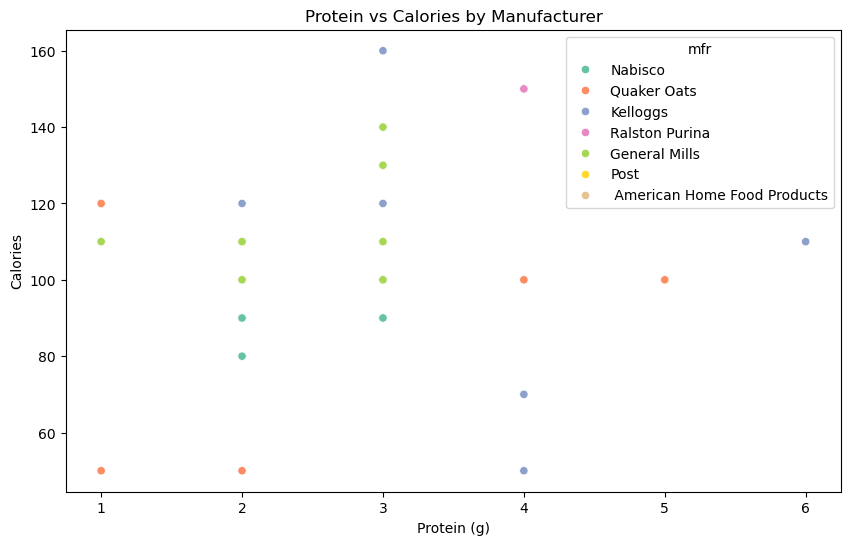

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cereal dataset
# df = pd.read_csv('/mnt/data/cereal.csv')

# Replace manufacturer codes with full names
# manufacturer_dict = {
#     'A': 'American Home Food Products', 
#     'G': 'General Mills',
#     'K': 'Kelloggs',
#     'N': 'Nabisco', 
#     'P': 'Post', 
#     'Q': 'Quaker Oats', 
#     'R': 'Ralston Purina'
# }
# df['mfr'].replace(manufacturer_dict, inplace=True)

# Create the scatter plot
plt.figure(figsize=(10, 6))
# sns.scatterplot(data=data, x='protein', y='calories', hue='mfr', palette='Set2', height=6, aspect=1.5, scatter_kws={"s": 50}, ci=None)
sns.scatterplot(data=data, x='protein', y='calories', hue='mfr', palette='Set2')

# Add title and labels
plt.title('Protein vs Calories by Manufacturer')
plt.xlabel('Protein (g)')
plt.ylabel('Calories')

# Display the plot
plt.show()


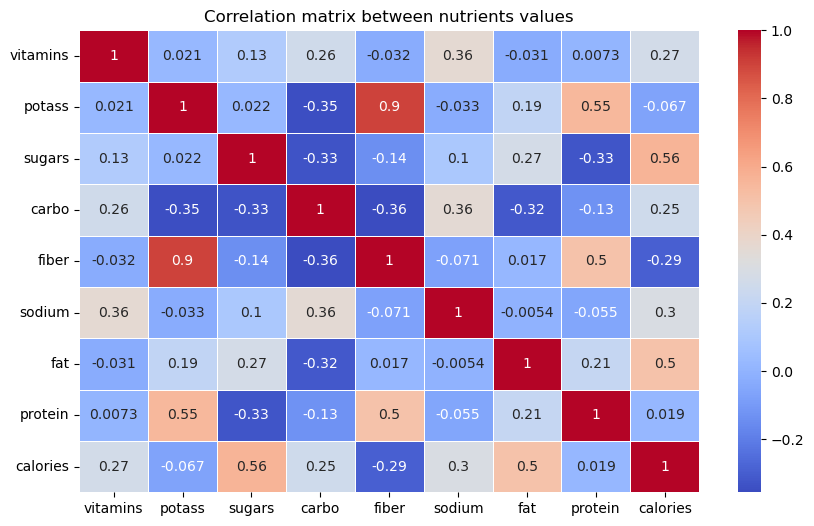

In [81]:
# 5. Using a heatmap, plot the correlation and covariance between all the nutritional values present in the cereals

selected = data[["vitamins","potass","sugars","carbo","fiber","sodium","fat","protein","calories"]]
correlation_matrix = selected.corr()
# correlation_matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot = True, cmap="coolwarm", linewidth = 0.5)
plt.title("Correlation matrix between nutrients values")
plt.show()

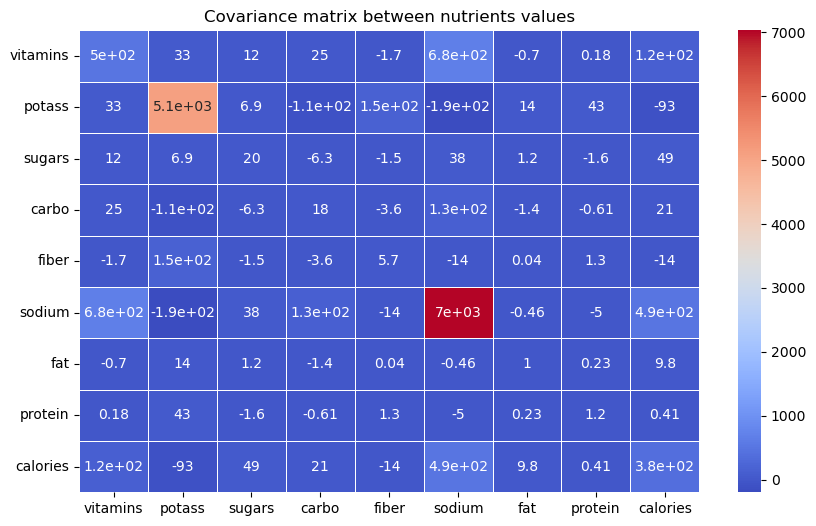

In [85]:
selected = data[["vitamins","potass","sugars","carbo","fiber","sodium","fat","protein","calories"]]
correlation_matrix = selected.cov()
# correlation_matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot = True, cmap="coolwarm", linewidth = 0.5)
plt.title("Covariance matrix between nutrients values")
plt.show()